In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import openpathsampling as paths
import aimmd 
import torch
import sys
import aimmdTIS
import openpathsampling.engines.toy as toys


fatal: not a git repository (or any of the parent directories): .git
/Users/rbreeba/miniconda3/envs/py39_AIMMD-TIS/lib/python3.9/site-packages/aimmd/base/storage.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
settings = {"n_harmonics": 0,
            "rotation_degrees": 0,
            "scale": 2}
pes = aimmdTIS.potential_switch("wolfe-quapp", settings)
n_harmonics = pes.n_harmonics

123
pot dimensions without oscillators: 2
harmonic oscillators omegas:
array([0., 0.])


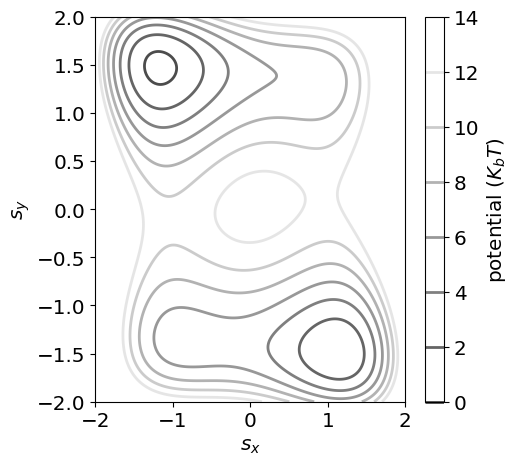

In [3]:
visualizer = aimmdTIS.ToyAimmdVisualizer(pes=pes)
visualizer.plot_potential_contour()

In [4]:
ResourceDirectoryPath = ""
aimmd_store = aimmd.Storage(ResourceDirectoryPath+"resources_toy_examples/aimmd_storage_WolfeQuapp.h5", "r")


ERROR:aimmd.base.storage:The directory containing the storage changed, but we have no write intent on file, so we can not update it. KerasRCModel saving might/will not work as expected if you did not copy the KerasRCmodel directory yourself.


In [5]:
model = aimmd_store.rcmodels["most_recent"]

In [6]:
# move model to current device:
use_gpu = False
if torch.cuda.is_available() and use_gpu:
    model = aimmdTIS.Tools.model_to(model, 'cuda')
elif torch.backends.mps.is_available() and use_gpu:
    model = aimmdTIS.Tools.model_to(model, 'mps')
else: 
    model = aimmdTIS.Tools.model_to(model, 'cpu')

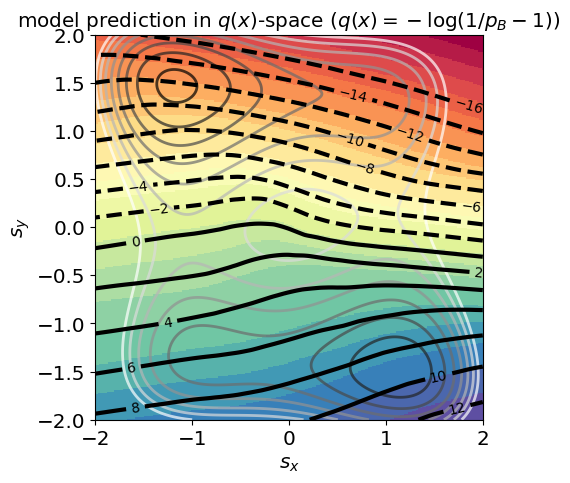

In [7]:
visualizer.q_space_2d_projection(model)

In [8]:

integ = toys.LangevinBAOABIntegrator(dt=0.02, temperature=0.1, gamma=2.5)
options={
    'integ' : integ,
    'n_frames_max' : 5000,
    'n_steps_per_frame' : 1
}
toy_eng = toys.Engine(
    options=options,
    topology=pes.topology
)
toy_eng.initialized = True

template = pes.template(toy_eng)
toy_eng.current_snapshot = template
paths.PathMover.engine = toy_eng

# Collective variables to define the states
opA = paths.CoordinateFunctionCV(name="opA", f=pes.stable_interface_function, center=pes.state_A)
opB = paths.CoordinateFunctionCV(name="opB", f=pes.stable_interface_function, center=pes.state_B)

# State volumes in CV space
stateA = paths.CVDefinedVolume(opA, 0.0, pes.state_boundary).named('StateA')
stateB = paths.CVDefinedVolume(opB, 0.0, pes.state_boundary).named('StateB')
#

In [9]:
descriptor_transform = paths.FunctionCV('descriptor_transform', lambda s: s.coordinates[0], cv_wrap_numpy_array=True).with_diskcache()


In [10]:
# Fake an initial trajectory
init_AB = paths.Trajectory(pes.simple_initial_path(100,toy_eng))


In [11]:
TIS_Framework = aimmdTIS.AIMMD_TIS(toy_eng, model, stateA, stateB, descriptor_transform=descriptor_transform)

In [12]:
storage = paths.Storage("simple_store_AIMMD_TIS.nc", "w", template=template)
storage.save(toy_eng)

(store.engines[DynamicsEngine] : 1 object(s),
 10,
 81631998736334399992372086154404560918)

In [13]:
print(storage.engines)

store.engines[DynamicsEngine] : 1 object(s)


In [14]:
interface_value = -6
TIS_Framework.run_single_TIS(100, storage, init_AB, interface_value)

Working on Monte Carlo cycle number 100
Running for 10 seconds -  0.10 seconds per step
Estimated time remaining: 0 seconds
DONE! Completed 100 Monte Carlo cycles.
snapshots: 7490
trajectories: 101
samples: 102
storing maximum q


/Users/rbreeba/miniconda3/envs/py39_AIMMD-TIS/lib/python3.9/site-packages/aimmdTIS/Toy_analysis.py:158: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_2d,y_2d,states_plot_A, colors='red',linewidth=self.linewidth_theory)
/Users/rbreeba/miniconda3/envs/py39_AIMMD-TIS/lib/python3.9/site-packages/aimmdTIS/Toy_analysis.py:159: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(x_2d,y_2d,states_plot_B, colors='blue', linewidth=self.linewidth_theory)


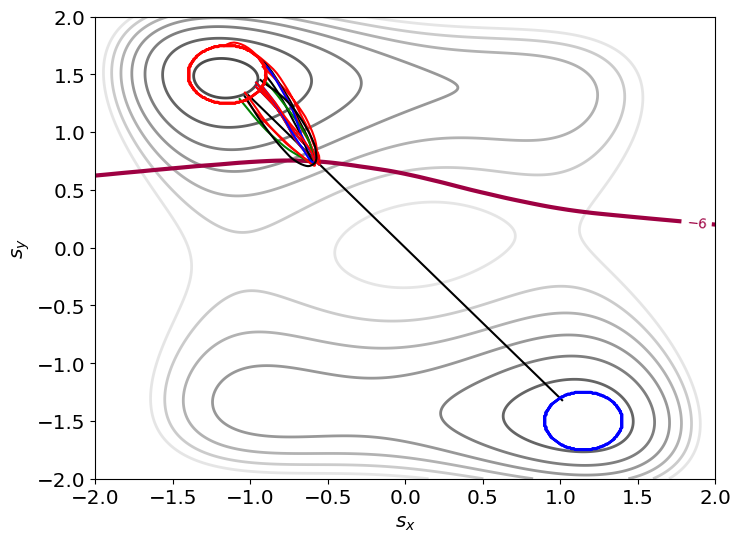

In [18]:
trajectories = [step.active[0].trajectory for step in storage.steps[::10]]
fig, ax = plt.subplots(1,1, figsize=(8,6))
visualizer.plot_potential_contour(ax=ax)
visualizer.plot_q_model_projection_contour(model, levels=[interface_value],ax=ax)
repcolordict = {0 : 'k-', 1 : 'r-', 2 : 'g-', 3 : 'b-', 4 : 'r-'}
for i, traj in enumerate(trajectories):
    ax.plot(traj.xyz[:,0,0], traj.xyz[:,0,1], repcolordict[i % 5])
visualizer.plot_states(ax=ax)


In [19]:
aimmd_store.close() 
storage.close()